# J08 — Redistribution, évaporation, prélèvement racinaire et bilan hydrique

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 8 : drainage interne, évaporation analytique, bilan hydrique saisonnier HYDRUS-1D, irrigation*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les projets HYDRUS-1D de référence sont dans `../../hydrus/` et se lisent avec `hydrus_io.py` (dossier `notebooks/`).
Les données propres à l'atelier sont dans `data/`. Convention HYDRUS : flux positif **vers le haut**, profondeurs négatives, unités cm et jours.

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special, integrate
from hydrus_io import read_tlevel, read_obs_node, read_nod_inf, read_balance, read_a_level

plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"

# sols de Carsel & Parrish (1988) : thr, ths, alpha, n, Ks (cm/j), l
SOLS = {"sable": [0.045, 0.430, 0.145, 2.68, 712.8, 0.5], "loam sableux": [0.065, 0.410, 0.075, 1.89, 106.1, 0.5],
        "loam": [0.078, 0.430, 0.036, 1.56, 24.96, 0.5], "loam limoneux": [0.067, 0.450, 0.020, 1.41, 10.80, 0.5],
        "argile": [0.068, 0.380, 0.008, 1.09, 4.80, 0.5]}

def vg_theta(h, p):
    thr, ths, a, n = p[:4]; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h)) ** n) ** (-m), 1.0)
    return thr + (ths - thr) * Se

def vg_K(h, p):
    thr, ths, a, n, Ks, l = p; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h)) ** n) ** (-m), 1.0)
    return Ks * Se ** l * (1 - (1 - Se ** (1 / m)) ** m) ** 2

LOAM = SOLS["loam"]

## Exercice 1 — Drainage interne et capacité au champ dynamique  *(≈ 15 min)*

Le projet `J08_redistribution_loam` simule le drainage interne d'un loam de 100 cm initialement à $h = -10$ cm
(surface couverte, flux nul ; drainage libre au bas ; 30 j ; nœuds d'observation à 10, 25, 50 et 90 cm).

1. Lire `OBS_NODE.OUT` (`read_obs_node`) et `T_LEVEL.OUT` (`read_tlevel`). Tracer $\theta(t)$ aux quatre profondeurs et
   $-v_{bot}(t)$ en log-log. Superposer $\theta(h=-100)$ et $\theta(h=-330$ cm$)$ du loam.
2. Ajuster une loi de puissance $q_d = a\,t^{-b}$ sur le flux de drainage et $\theta = a'\,t^{-b'}$ sur $\theta$ à 25 cm
   (`curve_fit`, $t > 1$ j). Interpréter les exposants.
3. Déterminer le temps $t_{cc}$ pour lequel $q_d$ passe sous 0,1 cm/j (1 mm/j), puis $\theta_{cc}$ à 25 cm à cet instant.
   Comparer à $\theta(-100)$ et $\theta(-330)$. Que devient $t_{cc}$ avec un critère de 0,01 cm/j ?
4. Bilan : stock initial et final (`Volume`), drainage cumulé (`sum(vBot)`), fermeture.

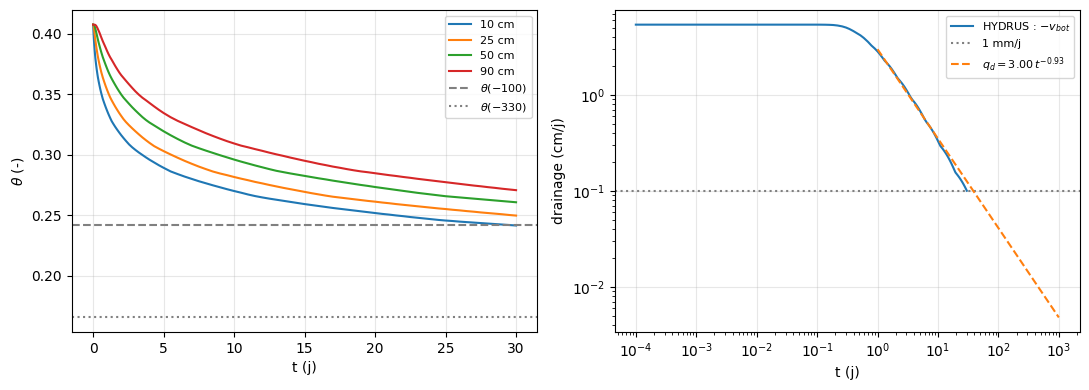

q_d = 3.005 t^-0.932 (cm/j) ; theta(25 cm) = 0.357 t^-0.104
Critère 0,1 cm/j : t_cc = 38.5 j, theta_cc(25 cm) = 0.244  |  theta(-100) = 0.242, theta(-330) = 0.165
Critère 0,01 cm/j : t_cc = 455 j (irréaliste à l'échelle d'une saison)
Stock initial 40.73 cm, final 25.81 cm : perte 14.92 cm ; drainage cumulé 14.92 cm ; écart -0.001 cm
WatBalR max (%) : 0.001


In [2]:
proj = f"{HYD}/J08_redistribution_loam"
tl = read_tlevel(proj)
ob = read_obs_node(proj)
noeuds = {11: 10, 26: 25, 51: 50, 91: 90}
th_100, th_330 = vg_theta(-100, LOAM), vg_theta(-330, LOAM)

# 1. tracés
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nd, z in noeuds.items():
    ax[0].plot(ob.index, ob[(nd, "theta")], label=f"{z} cm")
ax[0].axhline(th_100, color="gray", ls="--", label=r"$\theta(-100)$")
ax[0].axhline(th_330, color="gray", ls=":", label=r"$\theta(-330)$")
ax[0].set_xlabel("t (j)"); ax[0].set_ylabel(r"$\theta$ (-)"); ax[0].legend(fontsize=8)
ax[1].loglog(tl.index, -tl["vBot"], label="HYDRUS : $-v_{bot}$")
ax[1].axhline(0.1, color="gray", ls=":", label="1 mm/j")
ax[1].set_xlabel("t (j)"); ax[1].set_ylabel("drainage (cm/j)")

# 2. lois de puissance
f_pow = lambda t, a, b: a * t ** (-b)
m = tl.index > 1
(a_q, b_q), _ = optimize.curve_fit(f_pow, tl.index[m], -tl["vBot"][m], p0=[3, 1])
th25 = ob[(26, "theta")]; m2 = th25.index > 1
(a_t, b_t), _ = optimize.curve_fit(f_pow, th25.index[m2], th25[m2], p0=[0.35, 0.1])
tt = np.logspace(0, 3, 100)
ax[1].loglog(tt, f_pow(tt, a_q, b_q), "--", label=f"$q_d = {a_q:.2f}\\,t^{{-{b_q:.2f}}}$")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"q_d = {a_q:.3f} t^-{b_q:.3f} (cm/j) ; theta(25 cm) = {a_t:.3f} t^-{b_t:.3f}")

# 3. capacité au champ dynamique
t_cc = (a_q / 0.1) ** (1 / b_q)
th_cc = f_pow(t_cc, a_t, b_t)
t_cc2 = (a_q / 0.01) ** (1 / b_q)
print(f"Critère 0,1 cm/j : t_cc = {t_cc:.1f} j, theta_cc(25 cm) = {th_cc:.3f}  |  theta(-100) = {th_100:.3f}, theta(-330) = {th_330:.3f}")
print(f"Critère 0,01 cm/j : t_cc = {t_cc2:.0f} j (irréaliste à l'échelle d'une saison)")

# 4. bilan
V0, V30 = tl["Volume"].iloc[0], tl["Volume"].iloc[-1]
D30 = -tl["sum(vBot)"].iloc[-1]
print(f"Stock initial {V0:.2f} cm, final {V30:.2f} cm : perte {V0 - V30:.2f} cm ; drainage cumulé {D30:.2f} cm ; écart {V0 - V30 - D30:+.3f} cm")
bal = read_balance(proj)
print("WatBalR max (%) :", bal["WatBalR"].abs().max())

**Commentaire (instructeur).** Le flux de drainage décroît presque en $1/t$ ($b \approx 0{,}93$) et $\theta$ très lentement ($b' \approx 0{,}10$) : le drainage
« ne s'arrête jamais », il devient seulement négligeable. Avec le critère de 1 mm/j, $t_{cc} \approx 38$ j et $\theta_{cc} \approx 0{,}244$,
soit $\theta(h = -100$ cm$)$ : pour ce loam, la capacité au champ classique (pF 2) est retrouvée ; $-330$ cm (pF 2,5) sous-estimerait la réserve de 30 \%.
Le bilan ferme à mieux que 0,01 cm (drainage libre, pas d'autre flux).

## Exercice 2 — Évaporation : solution analytique par transformée de Kirchhoff  *(≈ 15 min)*

Modèle linéarisé (Gardner 1959 ; notes GAE-1004 §3.7) : $K = K_s e^{\alpha_G h}$ et $\theta - \theta_r = (\theta_s - \theta_r)e^{\alpha_G h}$,
donc $D = K_s/[\alpha_G(\theta_s-\theta_r)]$ est constante et $\Phi = \int_{-\infty}^h K\,dh = K/\alpha_G$. Pour un profil semi-infini
initialement à $h_i$ ($\Phi_i = K(h_i)/\alpha_G$) dont la surface sèche brusquement ($\Phi = 0$), le flux d'évaporation vaut

$$e_{sol}(t) = \frac{\Phi_i}{\sqrt{Dt}}\left[\frac{e^{-x^2}}{\sqrt{\pi}} - x\,\mathrm{erfc}(x)\right], \qquad x = \frac{\alpha_G}{2}\sqrt{Dt},$$

et, sans gravité ($\alpha_G \to 0$ dans le crochet), $e_{sol} = \Phi_i/\sqrt{\pi D t} = S_d/(2\sqrt t)$ avec la désorptivité $S_d = 2\Phi_i/\sqrt{\pi D}$.

1. Écrire `e_kirchhoff(t, Ks, alphaG, ths, thr, hi, gravite=True)` et calculer $D$, $\Phi_i$, $S_d$ pour le loam
   ($K_s = 24{,}96$ cm/j, $\alpha_G = 0{,}02$ cm$^{-1}$, $\theta_s = 0{,}43$, $\theta_r = 0{,}078$, $h_i = -50$ cm).
2. Évaporation réelle à deux stades : $e(t) = \min(e_p, e_{sol}(t))$. Pour $e_p$ = 0,3, 0,5 et 0,8 cm/j, tracer $e(t)$ et le cumul $E(t)$
   (`cumulative_trapezoid`) sur 10 j ; déterminer la durée $t_1$ du stade 1 et $E(10$ j$)$.
3. Vérifier le comportement en $t^{-1/2}$ : pente de $\log e_{sol}$ vs $\log t$ sur 0,001–0,01 j puis sur 0,05–0,5 j, avec et sans gravité.
   À partir de quel temps la gravité compte-t-elle ($x = \tfrac{\alpha_G}{2}\sqrt{Dt} \approx 0{,}1$) ?
4. Sensibilité : refaire pour $\alpha_G$ = 0,01 et 0,05 cm$^{-1}$ et pour $h_i$ = $-20$ et $-100$ cm. Commenter.

D = 3545 cm²/j ; K_i = 9.18 cm/j ; Phi_i = 459.1 cm²/j ; S_d = 8.70 cm/j^0.5


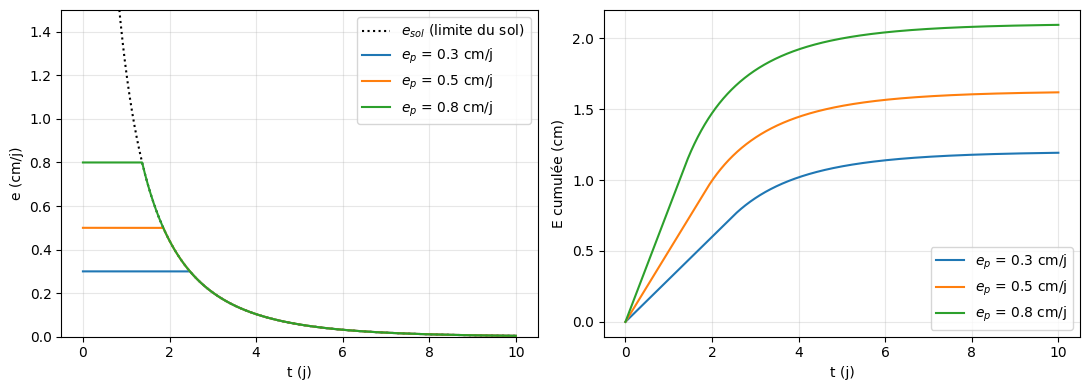

,e_p,t1_j,E_stade1,E_10j,E_potentielle
0,0.3,2.47,0.74,1.19,3.0
1,0.5,1.86,0.93,1.62,5.0
2,0.8,1.37,1.09,2.09,8.0


pente log-log sur 0.001-0.01 j, gravité=True : -0.531
pente log-log sur 0.001-0.01 j, gravité=False : -0.500
pente log-log sur 0.05-0.5 j, gravité=True : -0.756
pente log-log sur 0.05-0.5 j, gravité=False : -0.500
x = 0,1 atteint à t = 0.028 j : au-delà, la gravité accélère la décroissance de e_sol


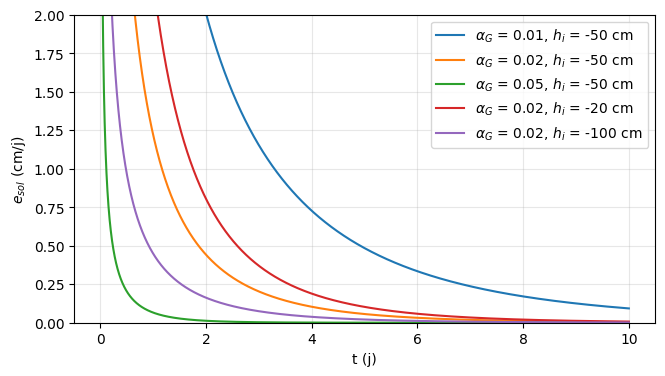

alphaG = 0.01, h_i = -50 : D = 7091 cm²/j, S_d = 20.29 cm/j^0.5, e_sol(1 j) = 4.320 cm/j
alphaG = 0.05, h_i = -50 : D = 1418 cm²/j, S_d = 1.23 cm/j^0.5, e_sol(1 j) = 0.066 cm/j
alphaG = 0.02, h_i = -20 : D = 3545 cm²/j, S_d = 15.85 cm/j^0.5, e_sol(1 j) = 2.216 cm/j
alphaG = 0.02, h_i = -100 : D = 3545 cm²/j, S_d = 3.20 cm/j^0.5, e_sol(1 j) = 0.447 cm/j


In [3]:
def e_kirchhoff(t, Ks, alphaG, ths, thr, hi, gravite=True):
    """Flux d'évaporation (cm/j) du modèle linéarisé K = Ks exp(alphaG h), surface à h -> -inf (Phi = 0)."""
    t = np.asarray(t, float)
    D = Ks / (alphaG * (ths - thr))                 # diffusivité constante (cm²/j)
    Phi_i = Ks * np.exp(alphaG * hi) / alphaG       # potentiel de Kirchhoff initial (cm²/j)
    if not gravite:
        return Phi_i / np.sqrt(np.pi * D * t)
    x = 0.5 * alphaG * np.sqrt(D * t)
    return Phi_i / np.sqrt(D * t) * (np.exp(-x ** 2) / np.sqrt(np.pi) - x * special.erfc(x))

Ks, aG, ths, thr, hi = 24.96, 0.02, 0.43, 0.078, -50.0
D = Ks / (aG * (ths - thr)); Phi_i = Ks * np.exp(aG * hi) / aG; S_d = 2 * Phi_i / np.sqrt(np.pi * D)
print(f"D = {D:.0f} cm²/j ; K_i = {Ks*np.exp(aG*hi):.2f} cm/j ; Phi_i = {Phi_i:.1f} cm²/j ; S_d = {S_d:.2f} cm/j^0.5")

# 2. deux stades
t = np.linspace(1e-4, 10, 5000)
e_sol = e_kirchhoff(t, Ks, aG, ths, thr, hi)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, e_sol, "k:", label="$e_{sol}$ (limite du sol)")
res = []
for ep in [0.3, 0.5, 0.8]:
    e = np.minimum(ep, e_sol)
    E = integrate.cumulative_trapezoid(e, t, initial=0)
    t1 = t[np.argmax(e_sol < ep)]
    res.append(dict(e_p=ep, t1_j=t1, E_stade1=ep * t1, E_10j=E[-1], E_potentielle=ep * 10))
    ax[0].plot(t, e, label=f"$e_p$ = {ep} cm/j"); ax[1].plot(t, E, label=f"$e_p$ = {ep} cm/j")
ax[0].set_ylim(0, 1.5); ax[0].set_xlabel("t (j)"); ax[0].set_ylabel("e (cm/j)"); ax[0].legend()
ax[1].set_xlabel("t (j)"); ax[1].set_ylabel("E cumulée (cm)"); ax[1].legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame(res).round(2))

# 3. comportement en t^-1/2
for t0, t1_ in [(1e-3, 1e-2), (0.05, 0.5)]:
    tt = np.logspace(np.log10(t0), np.log10(t1_), 50)
    for grav in [True, False]:
        pente = np.polyfit(np.log(tt), np.log(e_kirchhoff(tt, Ks, aG, ths, thr, hi, gravite=grav)), 1)[0]
        print(f"pente log-log sur {t0}-{t1_} j, gravité={grav} : {pente:.3f}")
t_x = (0.1 / (0.5 * aG)) ** 2 / D
print(f"x = 0,1 atteint à t = {t_x:.3f} j : au-delà, la gravité accélère la décroissance de e_sol")

# 4. sensibilité
fig, ax = plt.subplots(figsize=(7.5, 4))
for aa, hh in [(0.01, -50), (0.02, -50), (0.05, -50), (0.02, -20), (0.02, -100)]:
    ax.plot(t, e_kirchhoff(t, Ks, aa, ths, thr, hh), label=f"$\\alpha_G$ = {aa}, $h_i$ = {hh} cm")
ax.set_ylim(0, 2); ax.set_xlabel("t (j)"); ax.set_ylabel("$e_{sol}$ (cm/j)"); ax.legend(); plt.show()
for aa, hh in [(0.01, -50), (0.05, -50), (0.02, -20), (0.02, -100)]:
    Dd = Ks / (aa * (ths - thr)); Ph = Ks * np.exp(aa * hh) / aa
    print(f"alphaG = {aa}, h_i = {hh} : D = {Dd:.0f} cm²/j, S_d = {2*Ph/np.sqrt(np.pi*Dd):.2f} cm/j^0.5, e_sol(1 j) = {e_kirchhoff(1.0, Ks, aa, ths, thr, hh):.3f} cm/j")

**Commentaire (instructeur).** La pente log-log vaut exactement $-0{,}5$ sans gravité ; avec gravité elle vaut $-0{,}5$ aux temps très courts ($x \ll 1$, $t < 0{,}03$ j
pour ce loam à $K_s$ élevé) puis se raidit ($-0{,}8$ sur 0,05–0,5 j) : le stade 2 en $t^{-1/2}$ n'est qu'un comportement limite. Le stade 1 dure d'autant moins que $e_p$ est grand ($t_1 \propto 1/e_p^2$ sans gravité) ;
le cumul à 10 j varie peu avec $e_p$ (1,3 à 1,8 cm) : au-delà du stade 1, c'est le sol qui commande.
Un $\alpha_G$ grand (sol grossier, $K$ chute vite) ou un profil initialement sec ($h_i = -100$) réduisent fortement $\Phi_i$ et donc la désorptivité.

## Exercice 3 — Bilan hydrique d'une saison de maïs (HYDRUS-1D)  *(≈ 20 min)*

Le projet `J08_saison_culture_loam` simule 120 j de maïs sur un loam de 150 cm (condition atmosphérique avec ruissellement,
`hCritA` = 15 000 cm, drainage libre, Feddes maïs, racines linéaires 0–60 cm, $h_0 = -200$ cm). La météo est dans `data/J08_meteo_saison.csv`
(mm/j) : `pluie_mm`, `ET0_mm`, `Kc`, `LAI`, `ETc_mm`, `Ep_mm`, `Tp_mm`.

1. Recalculer $ET_c = K_c\,ET_0$, $E_p = ET_c\,e^{-0{,}463\,LAI}$ et $T_p = ET_c - E_p$ ; vérifier l'accord avec le fichier
   (écart max) et calculer les totaux saisonniers (mm).
2. Lire `T_LEVEL.OUT` : à $t = 120$ j, extraire `sum(Infil)`, `sum(Evap)`, `sum(vRoot)`, `sum(vBot)`, `sum(RunOff)`, `Volume` (initial et final).
   Écrire le bilan $P = I + R$, $\Delta S = I - E_a - T_a - D$ et vérifier la fermeture avec $\Delta$`Volume` ; calculer $E_a/E_p$ et $T_a/T_p$.
   Vérifier `WatBalR` dans `BALANCE.OUT`.
3. Indice de stress journalier : interpoler `sum(vRoot)` à chaque jour entier, en déduire $T_a$ journalier et $T_a/T_p$ ;
   tracer avec la pluie ; lister les périodes où $T_a/T_p < 0{,}5$.
4. Lire `OBS_NODE.OUT` : $\theta(t)$ à 10, 30, 60, 100 cm avec $\theta_{cc} = \theta(-100)$, $\theta_{pf} = \theta(-15\,000)$ et le seuil
   $\theta_{pf} + 0{,}5(\theta_{cc} - \theta_{pf})$. Puis, avec `data/J08_tensiometres.csv` (charges mesurées à 4 dates sur 0–60 cm),
   calculer $T_a/T_p = \omega = \int \alpha(h)\,b(z)\,dz$ par la fonction de Feddes non compensée (P0 = $-15$, POpt = $-30$, P2H = $-325$,
   P2L = $-600$, P3 = $-8000$ cm ; $h_3$ interpolé selon le $T_p$ du jour) avec $b(z)$ linéaire décroissante sur 0–60 cm, chaque tensiomètre
   représentant une tranche de 10 cm. Le projet HYDRUS utilise $\omega_c = 1$ (aucune compensation, bloc G de `SELECTOR.IN`) : comparer au
   rapport instantané `vRoot/rRoot` de `T_LEVEL.OUT` au même instant et discuter les sources d'écart. À titre théorique seulement : que donnerait
   une compensation avec $\omega_c = 0{,}5$ ($T_a/T_p = \min(1, \omega/\omega_c)$, Šimůnek & Hopmans 2009) ?

écart max ETc : 0.010 mm ; Ep : 0.008 ; Tp : 0.009
Totaux saisonniers (mm) :
pluie_mm    391.6
ET0_mm      583.8
ETc_mm      516.6
Ep_mm       145.0
Tp_mm       371.6
dtype: float64


,cm
P,39.160
R,0.000
I,39.160
Ea,12.314
Ta,26.529
D,2.286
dS (I-Ea-Ta-D),-1.969
dS (Volume),-2.025
erreur,0.056


P - I - R = -0.000 cm ; Ea/Ep = 0.849 ; Ta/Tp = 0.714
WatBalR max = 0.180 %


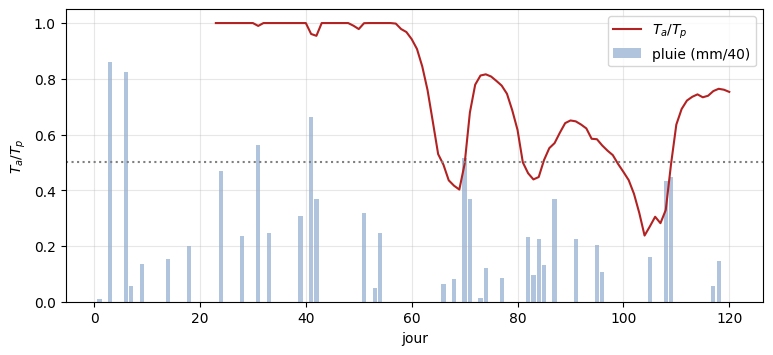

Jours avec Ta/Tp < 0,5 : [66, 67, 68, 69, 70, 82, 83, 84, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
nombre de jours de stress sévère : 19 ; Ta/Tp moyen sur la saison (pondéré) = 0.714


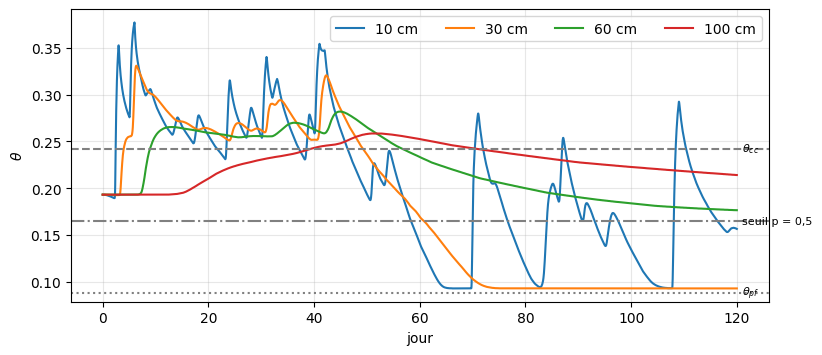

theta_cc = 0.242, theta_pf = 0.088, RU(0-60 cm) = 9.2 cm


,jour,Tp_cm_j,TaTp_Feddes_6_tensio,TaTp_HYDRUS_instantane,TaTp_HYDRUS_journalier,theorique_si_wc05
0,40,0.269,1.000,1.000,1.000,1.000
1,70,0.516,0.551,0.604,0.494,1.000
2,85,0.492,0.419,0.533,0.508,0.838
3,100,0.382,0.480,0.458,0.466,0.960


In [4]:
met = pd.read_csv("data/J08_meteo_saison.csv")
proj = f"{HYD}/J08_saison_culture_loam"

# 1. partition Ep / Tp
k = 0.463
ETc = met["Kc"] * met["ET0_mm"]
Ep = ETc * np.exp(-k * met["LAI"]); Tp = ETc - Ep
print(f"écart max ETc : {np.abs(ETc - met['ETc_mm']).max():.3f} mm ; Ep : {np.abs(Ep - met['Ep_mm']).max():.3f} ; Tp : {np.abs(Tp - met['Tp_mm']).max():.3f}")
tot = met[["pluie_mm", "ET0_mm", "ETc_mm", "Ep_mm", "Tp_mm"]].sum()
print("Totaux saisonniers (mm) :"); print(tot.round(1))

# 2. bilan à 120 j (cm)
tl = read_tlevel(proj)
fin = tl.iloc[-1]
I, Ea, Ta, D, R = fin["sum(Infil)"], fin["sum(Evap)"], fin["sum(vRoot)"], -fin["sum(vBot)"], fin["sum(RunOff)"]
V0, V1 = tl["Volume"].iloc[0], fin["Volume"]
P, Ep_tot, Tp_tot = tot["pluie_mm"] / 10, tot["Ep_mm"] / 10, tot["Tp_mm"] / 10
bilan = pd.Series({"P": P, "R": R, "I": I, "Ea": Ea, "Ta": Ta, "D": D, "dS (I-Ea-Ta-D)": I - Ea - Ta - D,
                   "dS (Volume)": V1 - V0, "erreur": (I - Ea - Ta - D) - (V1 - V0)}, name="cm")
display(bilan.round(3).to_frame())
print(f"P - I - R = {P - I - R:+.3f} cm ; Ea/Ep = {Ea/Ep_tot:.3f} ; Ta/Tp = {Ta/Tp_tot:.3f}")
bal = read_balance(proj)
print(f"WatBalR max = {bal['WatBalR'].abs().max():.3f} %")

# 3. indice de stress journalier
jours = np.arange(1, 121)
Ta_cum = np.interp(jours, tl.index, tl["sum(vRoot)"])
Ta_j = np.diff(np.concatenate([[0], Ta_cum]))                     # cm/j
Tp_j = met["Tp_mm"].to_numpy() / 10
ratio = np.where(Tp_j > 0.05, Ta_j / np.maximum(Tp_j, 1e-9), np.nan)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(jours, met["pluie_mm"] / 40, color="lightsteelblue", label="pluie (mm/40)")
ax.plot(jours, ratio, color="firebrick", label="$T_a/T_p$"); ax.axhline(0.5, color="gray", ls=":")
ax.set_xlabel("jour"); ax.set_ylabel("$T_a/T_p$"); ax.legend(); plt.show()
stress = jours[np.nan_to_num(ratio, nan=1) < 0.5]
print("Jours avec Ta/Tp < 0,5 :", stress.tolist())
print(f"nombre de jours de stress sévère : {len(stress)} ; Ta/Tp moyen sur la saison (pondéré) = {Ta_j.sum()/Tp_j.sum():.3f}")

# 4. teneur en eau aux 4 profondeurs et Feddes
ob = read_obs_node(proj)
th_cc, th_pf = vg_theta(-100, LOAM), vg_theta(-15000, LOAM)
fig, ax = plt.subplots(figsize=(9, 3.8))
for nd, z in {11: 10, 31: 30, 61: 60, 101: 100}.items():
    ax.plot(ob.index, ob[(nd, "theta")], label=f"{z} cm")
for val, lab, ls in [(th_cc, r"$\theta_{cc}$", "--"), (th_pf, r"$\theta_{pf}$", ":"), (th_pf + 0.5 * (th_cc - th_pf), "seuil p = 0,5", "-.")]:
    ax.axhline(val, color="gray", ls=ls); ax.text(121, val, lab, fontsize=8, va="center")
ax.set_xlabel("jour"); ax.set_ylabel(r"$\theta$"); ax.legend(loc="upper right", ncol=4); plt.show()
print(f"theta_cc = {th_cc:.3f}, theta_pf = {th_pf:.3f}, RU(0-60 cm) = {(th_cc - th_pf) * 60:.1f} cm")

def feddes(h, Tp, P0=-15, POpt=-30, P2H=-325, P2L=-600, P3=-8000, r2H=0.5, r2L=0.1):
    """Fonction de réduction de Feddes ; h3 interpolé entre P2H et P2L selon la demande Tp (cm/j)."""
    h = np.asarray(h, float)
    if Tp >= r2H: h3 = P2H
    elif Tp <= r2L: h3 = P2L
    else: h3 = P2L + (P2H - P2L) * (Tp - r2L) / (r2H - r2L)
    a = np.zeros_like(h)
    a = np.where((h <= POpt) & (h >= h3), 1.0, a)
    a = np.where((h < P0) & (h > POpt), (h - P0) / (POpt - P0), a)
    a = np.where((h < h3) & (h > P3), (h - P3) / (h3 - P3), a)
    return a

tens = pd.read_csv("data/J08_tensiometres.csv")
Lr = 60.0
rows = []
for jour, g in tens.groupby("jour"):
    z = g["profondeur_cm"].to_numpy(); h = g["h_cm"].to_numpy()
    Tp_d = met.loc[met["jour"] == jour, "Tp_mm"].iloc[0] / 10
    b = 2 / Lr * (1 - z / Lr)                    # b(z) linéaire, chaque tensiomètre représente 10 cm
    omega = np.sum(feddes(h, Tp_d) * b * 10)
    vR, rR = (np.interp(jour, tl.index, tl[c]) for c in ("vRoot", "rRoot"))
    rows.append(dict(jour=jour, Tp_cm_j=Tp_d, TaTp_Feddes_6_tensio=omega, TaTp_HYDRUS_instantane=vR / rR, TaTp_HYDRUS_journalier=ratio[jour - 1],
                     theorique_si_wc05=min(1.0, omega / 0.5)))
display(pd.DataFrame(rows).round(3))

**Commentaire (instructeur).** Le bilan ferme à 0,06 cm près (0,15 % des flux) : $I$ = 39,16, $E_a$ = 12,31, $T_a$ = 26,53, $D$ = 2,29 cm, $\Delta S$ = −2,03 cm.
$E_a/E_p$ = 0,85 (la surface sèche vite : `hCritA`) et $T_a/T_p$ = 0,71, avec trois épisodes de stress sévère ($T_a/T_p < 0{,}5$ : jours 66–70,
82–84 et 99–109), c'est-à-dire pendant la floraison–remplissage du maïs. HYDRUS applique exactement la fonction de Feddes non compensée
($\omega_c = 1$) : à chaque nœud, `Sink` = $\alpha(h)\,b(z)\,T_p$ et `vRoot` = $\int \alpha b\,T_p\,dz$. L'indice $\omega$ estimé à partir des 6 tensiomètres
(0,55 / 0,42 / 0,48 aux jours 70, 85, 100) retrouve donc le $T_a/T_p$ instantané d'HYDRUS (0,60 / 0,53 / 0,46) à 0,1 près ; l'écart restant vient
de l'échantillonnage (6 tranches de 10 cm contre 61 nœuds, bruit de 8 % sur $h$) et la valeur journalière diffère de la valeur instantanée
lorsqu'une pluie tombe dans la journée. La colonne théorique « si $\omega_c = 0{,}5$ » montre ce que changerait une compensation ; elle n'est pas activée ici.

## Exercice 4 — Calendrier d'irrigation à partir du bilan  *(≈ 15 min)*

Règle de pilotage : on irrigue lorsque le stock $S$ de la zone racinaire (0–60 cm) descend sous $S_{cc} - p\,RU$ avec $p = 0{,}5$,
d'une dose égale au déficit $S_{cc} - S$ (retour à la capacité au champ). $S_{cc} = \theta_{cc} Z_r$, $RU = (\theta_{cc} - \theta_{pf}) Z_r$.

1. Reconstituer le stock 0–60 cm jour par jour à partir des nœuds d'observation : $S = 20\,\theta_{10} + 25\,\theta_{30} + 15\,\theta_{60}$ (cm)
   et tracer avec $S_{cc}$, le seuil et $S_{pf}$. Quel jour le seuil est-il franchi pour la première fois ?
2. Simuler le calendrier : partir de la série HYDRUS et de ses variations journalières $\Delta S_H$ ; une fois irrigué, on suppose que la culture
   transpire à $T_p$ (on retranche en plus le déficit $T_p - T_a$ de la simulation pluviale) et que l'excédent au-dessus de $S_{cc}$ draine.
   Construire la liste des irrigations (jour, dose) et le volume saisonnier (mm et m³/ha).
3. Refaire pour $p = 0{,}3$ et $p = 0{,}7$ ; comparer nombre d'irrigations, doses et volume total. Quelle règle recommander ?

S_cc = 14.5 cm, S_pf = 5.3 cm, RU = 9.2 cm, RFU(p=0,5) = 4.6 cm


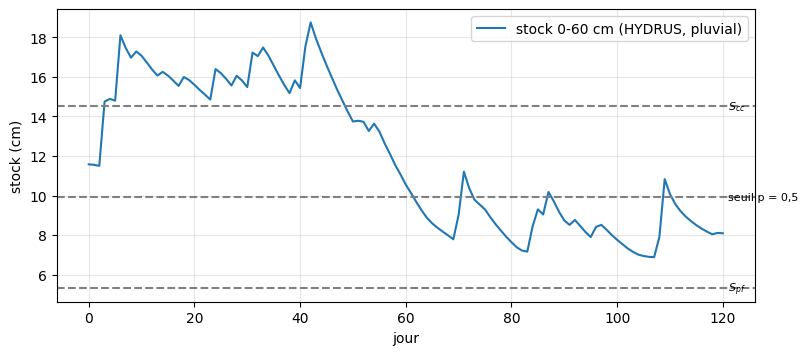

premier franchissement du seuil (9.9 cm) au jour 62


,jour,dose_mm,dose_brute_mm
0,62,48.5,57.1
1,79,48.7,57.3
2,100,49.4,58.2


p = 0,5 : 3 irrigations, volume net 147 mm = 1467 m³/ha ; brut (eff. 0,85) 173 mm


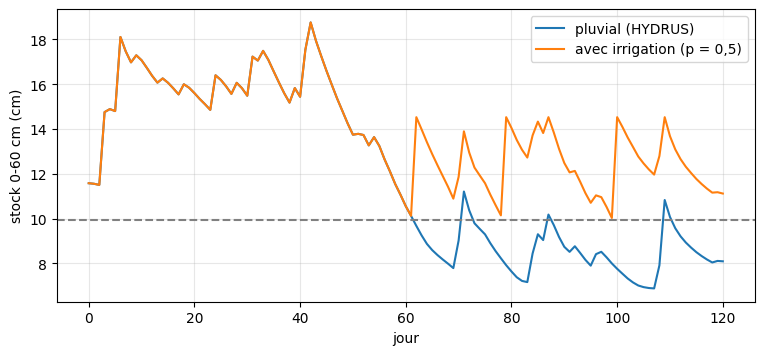

,p,n_irrigations,dose_moy_mm,volume_mm,premiere,derniere
0,0.3,7,29.5,206.7,58,116
1,0.5,3,48.9,146.7,62,100
2,0.7,2,65.2,130.3,68,91


In [5]:
proj = f"{HYD}/J08_saison_culture_loam"
ob = read_obs_node(proj); tl = read_tlevel(proj)
jours = np.arange(0, 121)
th10, th30, th60 = (np.interp(jours, ob.index, ob[(nd, "theta")]) for nd in (11, 31, 61))
S_H = 20 * th10 + 25 * th30 + 15 * th60
Zr = 60.0
S_cc, S_pf = vg_theta(-100, LOAM) * Zr, vg_theta(-15000, LOAM) * Zr
RU = S_cc - S_pf
print(f"S_cc = {S_cc:.1f} cm, S_pf = {S_pf:.1f} cm, RU = {RU:.1f} cm, RFU(p=0,5) = {0.5*RU:.1f} cm")

# 1. stock pluvial
seuil = S_cc - 0.5 * RU
j1 = jours[np.argmax(S_H < seuil)]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(jours, S_H, label="stock 0-60 cm (HYDRUS, pluvial)")
for v, lab in [(S_cc, "$S_{cc}$"), (seuil, "seuil p = 0,5"), (S_pf, "$S_{pf}$")]:
    ax.axhline(v, color="gray", ls="--"); ax.text(121, v, lab, fontsize=8, va="center")
ax.set_xlabel("jour"); ax.set_ylabel("stock (cm)"); ax.legend(); plt.show()
print(f"premier franchissement du seuil ({seuil:.1f} cm) au jour {j1}")

# 2. calendrier d'irrigation
Ta_cum = np.interp(jours, tl.index, tl["sum(vRoot)"]); Ta_j = np.diff(Ta_cum)
Tp_j = met["Tp_mm"].to_numpy() / 10
dS_H = np.diff(S_H)

def calendrier(p, eff=0.85):
    """Simule la règle d'irrigation sur la base des variations journalières de la simulation pluviale."""
    S = S_H[0]; irrig = []; irrigue = False; traj = [S]
    for j in range(120):
        if irrigue:
            dS = dS_H[j] - (Tp_j[j] - Ta_j[j])       # après irrigation : la culture transpire à Tp
            S = min(S + dS, S_cc)                    # l'excédent au-dessus de S_cc draine
        else:
            S = S_H[j + 1]                           # avant la première irrigation : trajectoire HYDRUS
        if S < S_cc - p * RU and Tp_j[j] > 0.1:                        # seuil atteint (et culture active)
            dose = S_cc - S
            irrig.append(dict(jour=j + 1, dose_mm=10 * dose, dose_brute_mm=10 * dose / eff))
            S = S_cc; irrigue = True
        traj.append(S)
    return pd.DataFrame(irrig), np.array(traj)

cal, traj = calendrier(0.5)
display(cal.round(1))
print(f"p = 0,5 : {len(cal)} irrigations, volume net {cal['dose_mm'].sum():.0f} mm = {10*cal['dose_mm'].sum():.0f} m³/ha ; brut (eff. 0,85) {cal['dose_brute_mm'].sum():.0f} mm")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(jours, S_H, label="pluvial (HYDRUS)"); ax.plot(jours, traj, label="avec irrigation (p = 0,5)")
ax.axhline(seuil, color="gray", ls="--"); ax.set_xlabel("jour"); ax.set_ylabel("stock 0-60 cm (cm)"); ax.legend(); plt.show()

# 3. sensibilité à p
rows = []
for p in [0.3, 0.5, 0.7]:
    c, _ = calendrier(p)
    rows.append(dict(p=p, n_irrigations=len(c), dose_moy_mm=c["dose_mm"].mean(), volume_mm=c["dose_mm"].sum(),
                     premiere=c["jour"].min(), derniere=c["jour"].max()))
display(pd.DataFrame(rows).round(1))

**Commentaire (instructeur).** Le seuil $p = 0{,}5$ (RFU ≈ 46 mm) est franchi au jour 62 ; il faut ensuite trois apports d'environ 49 mm (jours 62, 79, 100), soit
≈ 150 mm nets (1500 m³/ha, 170 mm bruts à 85 % d'efficience), un complément modeste pour un maïs en climat tempéré humide (392 mm de pluie).
Un $p$ faible (0,3) multiplie les petits apports (bon pour l'aspersion pivot ou le goutte-à-goutte), un $p$ élevé (0,7) laisse la culture
subir un stress avant chaque apport : pour le maïs en floraison, on retient $p \le 0{,}5$. Le calendrier reste indicatif : il suppose
que l'irrigation rétablit $T_a = T_p$ sans changer $E_a$ ni le drainage ; la simulation HYDRUS avec irrigation (bonus) lève cette hypothèse.

## Exercice 5 — Bonus — modèle de bilan à un réservoir  *(≈ facultatif)*

Écrire un modèle journalier à un réservoir (zone racinaire 0–60 cm, réserve utile $RU$) :
$S_{t} = S_{t-1} + P_t + I_{r,t} - E_{a,t} - T_{a,t} - D_t$ avec $T_a = T_p\min(1, S/((1-p)RU))$ (FAO-56, $p = 0{,}5$),
$E_a = E_p\min(1, S/RU)$, $D = \max(0, S - RU)$ ($S$ = eau disponible au-dessus de $\theta_{pf}$).
Initialiser avec $\theta_0 = \theta(-200$ cm$)$. Comparer $T_a$, $E_a$, $D$ cumulés et $T_a/T_p$ journalier à HYDRUS, puis rejouer avec
le calendrier d'irrigation de l'exercice 4.

,HYDRUS (pluvial),réservoir (pluvial),réservoir + irrigation
Ea (cm),12.31,8.68,10.82
Ta (cm),26.53,25.34,35.39
D (cm),2.29,8.34,8.34
Ta/Tp,0.71,0.68,0.95


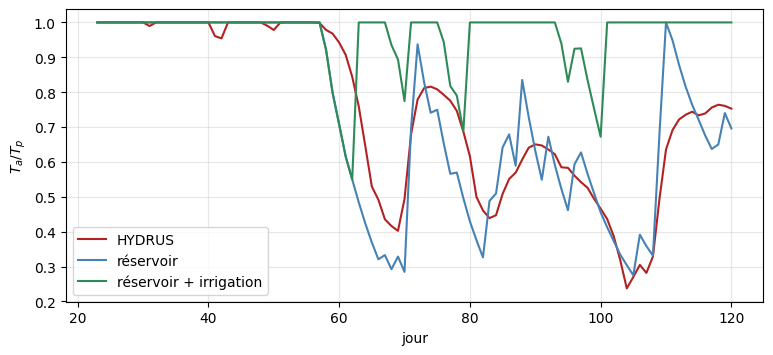

In [6]:
def reservoir(P, Ep, Tp, Ir, RU, S0, p=0.5):
    """Bilan journalier à un réservoir (cm). S = eau disponible au-dessus du point de flétrissement."""
    S = S0; out = []
    for Pt, Ept, Tpt, It in zip(P, Ep, Tp, Ir):
        Ta = Tpt * min(1.0, S / ((1 - p) * RU))
        Ea = Ept * min(1.0, S / RU)
        S = S + Pt + It - Ea - Ta
        Dr = max(0.0, S - RU); S -= Dr
        out.append(dict(S=S, Ea=Ea, Ta=Ta, D=Dr))
    return pd.DataFrame(out, index=np.arange(1, len(P) + 1))

P = met["pluie_mm"].to_numpy() / 10; Ep_j = met["Ep_mm"].to_numpy() / 10
S0 = (vg_theta(-200, LOAM) - vg_theta(-15000, LOAM)) * Zr
Ir0 = np.zeros(120)
r0 = reservoir(P, Ep_j, Tp_j, Ir0, RU, S0)
Ir1 = np.zeros(120)
for _, row in cal.iterrows():
    Ir1[int(row["jour"]) - 1] = row["dose_mm"] / 10
r1 = reservoir(P, Ep_j, Tp_j, Ir1, RU, S0)
comp = pd.DataFrame({"HYDRUS (pluvial)": [Ea, Ta, D, Ta / Tp_tot],
                     "réservoir (pluvial)": [r0["Ea"].sum(), r0["Ta"].sum(), r0["D"].sum(), r0["Ta"].sum() / Tp_j.sum()],
                     "réservoir + irrigation": [r1["Ea"].sum(), r1["Ta"].sum(), r1["D"].sum(), r1["Ta"].sum() / Tp_j.sum()]},
                    index=["Ea (cm)", "Ta (cm)", "D (cm)", "Ta/Tp"])
display(comp.round(2))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(jours[1:], ratio, color="firebrick", label="HYDRUS")
ax.plot(r0.index, np.where(Tp_j > 0.05, r0["Ta"] / np.maximum(Tp_j, 1e-9), np.nan), color="steelblue", label="réservoir")
ax.plot(r1.index, np.where(Tp_j > 0.05, r1["Ta"] / np.maximum(Tp_j, 1e-9), np.nan), color="seagreen", label="réservoir + irrigation")
ax.set_xlabel("jour"); ax.set_ylabel("$T_a/T_p$"); ax.legend(); plt.show()

**Commentaire (instructeur).** Le réservoir retrouve $T_a$ (25,3 contre 26,5 cm) et le calendrier des stress, mais sous-estime $E_a$ (8,7 contre 12,3 cm : pas de stade 2
explicite) et surestime le drainage (8,3 contre 2,3 cm) : toute l'eau au-delà de $RU$ est perdue immédiatement, alors qu'HYDRUS la stocke
sous 60 cm, la laisse drainer lentement (exercice 1) et la restitue en partie par remontée capillaire. Avec le calendrier de l'exercice 4,
$T_a/T_p$ remonte à 0,95 : l'objectif de la règle est atteint. C'est l'outil de pilotage courant ; HYDRUS
sert à le caler (RU, $p$) et à vérifier le drainage et le lessivage.

## Pour aller plus loin

* Refaire l'exercice 1 avec un profil stratifié (loam sur sable, J7) : comment la barrière capillaire modifie-t-elle $\theta_{cc}$ ?
* Comparer la solution de Kirchhoff (exercice 2) à une simulation HYDRUS-1D d'évaporation (condition atmosphérique, `hCritA` = $10^6$ cm).
* Dans HYDRUS-1D, ajouter les irrigations de l'exercice 4 à `Prec` dans `ATMOSPH.IN` et comparer $T_a/T_p$, drainage et stock.